# 서울시 자치구 폐기물 조정지표 분석

**목표**: 인구·사업체 활동 규모를 통제한 회귀모형으로 자치구별 **예측 발생량**을 산출하고,
실제 발생량과의 비율(=**조정지표**)로 자치구를 5분류한다.

$$\text{조정지표} = \frac{\text{실제 발생량}}{\text{예측 발생량}}$$

| 조정지표 | 분류 | 정책 시사점 |
|---|---|---|
| ≤ 0.8 | 우수 | 모범 사례 — 타 구 확산 후보 |
| 0.8 ~ 0.9 | 양호 | 평균 대비 적게 배출 |
| 0.9 ~ 1.1 | 적정 | 예상 범위 내 |
| 1.1 ~ 1.2 | 주의 | 평균 대비 다소 많이 배출 |
| ≥ 1.2 | 과다 | 감량 정책 우선 개입 대상 |

**핵심 철학**: 회귀의 목적은 "정답 맞히기"가 아니라 "구조적 차이를 통제한 후의 예외 식별".
잔차(=조정지표가 1.0에서 벗어난 정도)가 곧 정책 메시지다.

**모형 단계**
| 모형 | 식 | 의도 |
|---|---|---|
| M1 | daily ~ 거주인구 | 베이스라인 — 인구 1축으로 어디까지? |
| M2 | + 주간유입인구 | 외부 유입의 폐기물 기여 |
| M3 | + 종사자수 | 사업장 활동 기여 |
| M4 | + 4유형 더미 | 유형별 baseline 차이 (선택) |

**산출물**: `data/preprocess/gu_waste_adjusted.csv` (25행 × 10컬럼)


## Step 0. 환경 셋업

라이브러리 임포트, 경로 정의, 한글 폰트 설정, 자치구 코드 매핑.
**회귀 분석은 statsmodels 사용** (sklearn은 통계적 진단을 못함).

In [1]:
import os, sys, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as scistats

warnings.filterwarnings("ignore")
pd.set_option("display.unicode.east_asian_width", True)
pd.set_option("display.max_columns", 50)

# 한글 폰트 폴백
for fn in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    try:
        mpl.rcParams["font.family"] = fn
        mpl.rcParams["axes.unicode_minus"] = False
        break
    except Exception:
        continue

# 경로 (notebooks/ 기준 ../data)
NB_DIR     = os.path.abspath(os.getcwd())
PROJ_ROOT  = os.path.abspath(os.path.join(NB_DIR, ".."))
DATA_DIR   = os.path.join(PROJ_ROOT, "data")
PREPROC_DIR = os.path.join(DATA_DIR, "preprocess")
os.makedirs(PREPROC_DIR, exist_ok=True)

print("DATA_DIR   :", DATA_DIR)
print("PREPROC_DIR:", PREPROC_DIR)

# 자치구 코드 매핑 (생활인구 raw에서 사용)
GU_CODE_MAP = {
    11110: "종로구",   11140: "중구",     11170: "용산구",   11200: "성동구",
    11215: "광진구",   11230: "동대문구", 11260: "중랑구",   11290: "성북구",
    11305: "강북구",   11320: "도봉구",   11350: "노원구",   11380: "은평구",
    11410: "서대문구", 11440: "마포구",   11470: "양천구",   11500: "강서구",
    11530: "구로구",   11545: "금천구",   11560: "영등포구", 11590: "동작구",
    11620: "관악구",   11650: "서초구",   11680: "강남구",   11710: "송파구",
    11740: "강동구",
}
assert len(GU_CODE_MAP) == 25
print("GU_CODE_MAP: 25개 매핑")

DATA_DIR   : d:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data
PREPROC_DIR: d:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data\preprocess
GU_CODE_MAP: 25개 매핑


**검증 — Step 0**: 라이브러리 버전과 필수 입력 파일 확인.

In [2]:
import sklearn, statsmodels
print("pandas     :", pd.__version__)
print("numpy      :", np.__version__)
print("statsmodels:", statsmodels.__version__)
print("sklearn    :", sklearn.__version__)
print()

REQUIRED = {
    "분류 결과":     os.path.join(PREPROC_DIR, "gu_classified.csv"),
    "폐기물(daily)": os.path.join(PREPROC_DIR, "per_capita.csv"),
    "사업체 xlsx":   os.path.join(DATA_DIR, "사업체현황_2024.xlsx"),
    "생활인구 csv":  os.path.join(DATA_DIR, "생활인구_2024.csv"),
}

missing = []
for label, p in REQUIRED.items():
    ok = os.path.exists(p)
    print(f"  [{'OK' if ok else 'MISSING'}] {label:14s} {p}")
    if not ok: missing.append(label)

if "분류 결과" in missing:
    raise FileNotFoundError(
        "gu_classified.csv 가 없습니다. "
        "분류 노트북(04_classify_gu_4type.ipynb)을 먼저 실행하세요."
    )
if missing:
    raise FileNotFoundError(f"다음 파일이 없습니다: {missing}")

print("\n✅ 필수 파일 모두 존재")

pandas     : 2.2.3
numpy      : 1.26.4
statsmodels: 0.14.0
sklearn    : 1.2.2

  [OK] 분류 결과          d:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data\preprocess\gu_classified.csv
  [OK] 폐기물(daily)     d:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data\preprocess\per_capita.csv
  [OK] 사업체 xlsx       d:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data\사업체현황_2024.xlsx
  [OK] 생활인구 csv       d:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data\생활인구_2024.csv

✅ 필수 파일 모두 존재


## Step 1. 통합 테이블 구성

25개 자치구 × 회귀 입력 컬럼이 모두 들어간 마스터 테이블 `df` 생성.

1-1. 분류 결과(`gu_classified.csv`) → 자치구·거주인구·유형
1-2. 폐기물(`per_capita.csv`) → daily (톤/일, 종속변수)
1-3. 사업체 xlsx → 종사자수
1-4. 생활인구 raw → 평일 14시 평균 인구
1-5. 머지 + 주간유입인구 = 평일14시인구 - 거주인구

In [29]:
# 1-1. 분류 결과 로드
gu_class = pd.read_csv(os.path.join(PREPROC_DIR, "gu_classified.csv"),
                       encoding="utf-8-sig")
print("gu_classified.csv shape:", gu_class.shape)
print("컬럼:", gu_class.columns.tolist())
gu_class = gu_class[["자치구", "거주인구", "유형"]].copy()
gu_class.head()

gu_classified.csv shape: (25, 11)
컬럼: ['자치구', '거주인구', 'B1_평균규모', 'B2_오피스비', 'B3_소비관광비', 'B4_생활밀착비', 'L1_주야비', 'L2_주말비', 'L3_야간거주비', '유형', 'kmeans_label']


,자치구,거주인구,유형
0,종로구,149608,상업형
1,중구,131214,상업형
2,용산구,217194,유동집중형
3,성동구,281289,혼합형
4,광진구,348652,유동집중형


In [4]:
# 1-2. 폐기물 발생량 로드
df_pc = pd.read_csv(os.path.join(PREPROC_DIR, "per_capita.csv"))
print("per_capita.csv shape:", df_pc.shape)
print("컬럼:", df_pc.columns.tolist())
df_pc = df_pc[["district", "daily"]].rename(columns={"district": "자치구"})
df_pc.head()

per_capita.csv shape: (25, 4)
컬럼: ['district', 'daily', 'pop', 'perCap']


,자치구,daily
0,종로구,270.2
1,중구,365.0
2,용산구,283.9
3,성동구,435.1
4,광진구,293.0


In [5]:
# 1-3. 종사자수 추출 (사업체 xlsx 다시 로드, 분류 노트북 Step 1과 동일 구조)
path_biz = os.path.join(DATA_DIR, "사업체현황_2024.xlsx")
raw = pd.read_excel(path_biz, sheet_name="데이터", skiprows=5, header=None,
                    engine="openpyxl")
print("raw shape:", raw.shape)

# 컬럼명: 0=동별1, 1=자치구, 2=사업체수_총_소계, 3=사업체수_총_여성,
#         4=종사자수_총_소계 (이번 노트북에서 필요한 것)
raw.columns = [f"col_{i}" for i in range(raw.shape[1])]
raw = raw.rename(columns={"col_0": "동별1", "col_1": "자치구",
                          "col_4": "종사자수_총_소계"})

# 첫 행(서울시 합계: 동별1='합계') 제외
if str(raw.iloc[0]["동별1"]).strip() == "합계":
    raw = raw.iloc[1:].copy()

emp_df = raw[["자치구", "종사자수_총_소계"]].reset_index(drop=True)
emp_df["종사자수_총_소계"] = emp_df["종사자수_총_소계"].astype(int)
print("종사자수 테이블 shape:", emp_df.shape)
emp_df.head()

raw shape: (26, 45)
종사자수 테이블 shape: (25, 2)


,자치구,종사자수_총_소계
0,종로구,265635
1,중구,399960
2,용산구,157564
3,성동구,201023
4,광진구,125475


In [6]:
# 1-4. 평일 14시 평균 인구 추출 (생활인구 raw 로드)
path_lv = os.path.join(DATA_DIR, "생활인구_2024.csv")
USE_COLS = ["stdr_de_id", "tmzon_pd_se", "adstrd_code_se", "tot_lvpop_co"]
df_lv = pd.read_csv(path_lv, encoding="utf-8-sig",
                    usecols=USE_COLS,
                    dtype={"stdr_de_id": np.int32,
                           "tmzon_pd_se": np.int8,
                           "adstrd_code_se": np.int32,
                           "tot_lvpop_co": np.float32})
print("생활인구 raw shape:", df_lv.shape)

# 자치구 매핑
df_lv["자치구"] = df_lv["adstrd_code_se"].map(GU_CODE_MAP)
n_unmapped = df_lv["자치구"].isna().sum()
print(f"매핑 안 된 행: {n_unmapped:,}")

# 날짜 → 요일 → is_weekend
df_lv["날짜"] = pd.to_datetime(df_lv["stdr_de_id"], format="%Y%m%d")
df_lv["요일"] = df_lv["날짜"].dt.weekday  # 0=월, 6=일
df_lv["is_weekend"] = df_lv["요일"] >= 5

# 평일 14시 필터링 → 자치구별 평균
mask_wd14 = (~df_lv["is_weekend"]) & (df_lv["tmzon_pd_se"] == 14)
lv14 = (df_lv[mask_wd14]
        .groupby("자치구")["tot_lvpop_co"].mean()
        .reset_index()
        .rename(columns={"tot_lvpop_co": "평일14시인구"}))
lv14["평일14시인구"] = lv14["평일14시인구"].astype(float)
print("평일14시 자치구 수:", lv14.shape[0])
lv14.head()

생활인구 raw shape: (219600, 4)
매핑 안 된 행: 0
평일14시 자치구 수: 25


,자치구,평일14시인구
0,강남구,1.083110e+06
1,강동구,4.588694e+05
2,강북구,2.388053e+05
3,강서구,5.222511e+05
4,관악구,3.889286e+05


In [7]:
# 1-5. 모든 데이터 머지
df = (gu_class
      .merge(df_pc,  on="자치구", how="left")
      .merge(emp_df, on="자치구", how="left")
      .merge(lv14,   on="자치구", how="left"))
df["주간유입인구"] = df["평일14시인구"] - df["거주인구"]

# 컬럼 정렬
df = df[["자치구", "유형", "daily",
         "거주인구", "평일14시인구", "주간유입인구",
         "종사자수_총_소계"]].rename(
    columns={"종사자수_총_소계": "종사자수"}
)
print("마스터 테이블 shape:", df.shape)
df.head()

마스터 테이블 shape: (25, 7)


,자치구,유형,daily,거주인구,평일14시인구,주간유입인구,종사자수
0,종로구,상업형,270.2,149608,396429.18750,246821.18750,265635
1,중구,상업형,365.0,131214,436703.46875,305489.46875,399960
2,용산구,유동집중형,283.9,217194,304268.25000,87074.25000,157564
3,성동구,혼합형,435.1,281289,361614.31250,80325.31250,201023
4,광진구,유동집중형,293.0,348652,334800.09375,-13851.90625,125475


**검증 — Step 1**: 25개 자치구 × 결측 0 × 합계 검증 + 직관 검증.

In [8]:
assert df.shape[0] == 25, f"자치구 수 이상: {df.shape[0]}"
assert df.isna().sum().sum() == 0, f"결측치 존재: \n{df.isna().sum()}"

print(f"shape: {df.shape}")
print(f"결측치 합계: {df.isna().sum().sum()}")
print(f"자치구 수: {df['자치구'].nunique()}")
print()
print(f"거주인구 합계  : {df['거주인구'].sum():>12,} (서울 ~9,597,372)")
print(f"종사자수 합계  : {df['종사자수'].sum():>12,} (서울 ~5,772,456)")
print(f"daily 합계     : {df['daily'].sum():>12,.1f} 톤/일")
print(f"평일14시 합계  : {df['평일14시인구'].sum():>12,.0f}")
print()

# 직관 검증: 주간유입인구 분포
print("=== 주간유입인구 TOP 5 (양수 큰 값 기대: 강남·중구·종로·서초·영등포) ===")
print(df.nlargest(5, "주간유입인구")[["자치구", "주간유입인구"]].to_string(index=False))
print()
print("=== 주간유입인구 BOTTOM 5 (음수 또는 작은 값 기대: 노원·도봉·중랑) ===")
print(df.nsmallest(5, "주간유입인구")[["자치구", "주간유입인구"]].to_string(index=False))
print()

assert 9_400_000 <= df["거주인구"].sum() <= 9_700_000, "거주인구 합계 이상"
assert 5_500_000 <= df["종사자수"].sum() <= 6_000_000, "종사자수 합계 이상"
assert 5_000 <= df["daily"].sum() <= 12_000, "daily 합계 이상"

print("✅ Step 1 검증 통과")

shape: (25, 7)
결측치 합계: 0
자치구 수: 25

거주인구 합계  :    9,597,372 (서울 ~9,597,372)
종사자수 합계  :    5,772,456 (서울 ~5,772,456)
daily 합계     :     10,483.7 톤/일
평일14시 합계  :   10,693,653

=== 주간유입인구 TOP 5 (양수 큰 값 기대: 강남·중구·종로·서초·영등포) ===
  자치구  주간유입인구
  강남구  519895.00000
    중구  305489.46875
  서초구  296232.06250
  종로구  246821.18750
영등포구  166566.87500

=== 주간유입인구 BOTTOM 5 (음수 또는 작은 값 기대: 노원·도봉·중랑) ===
자치구  주간유입인구
은평구 -111048.03125
양천구 -110674.90625
관악구 -106691.43750
중랑구  -96126.43750
도봉구  -79430.06250

✅ Step 1 검증 통과


## Step 2. 탐색적 데이터 분석 (EDA)

회귀 적합 전, 변수 분포와 관계를 시각적으로 확인.
- 종속변수 daily 분포 (왜도)
- daily ↔ 각 독립변수 산점도
- 변수 간 상관관계 (다중공선성 사전 체크)

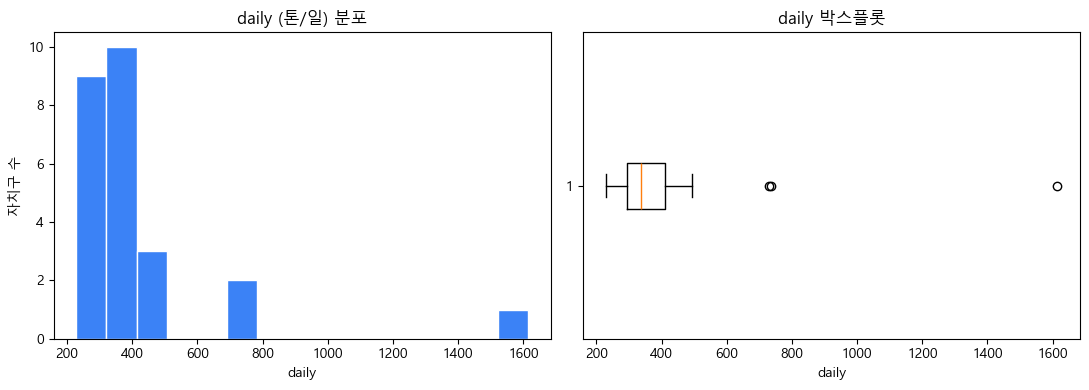

=== daily describe ===
count      25.00
mean      419.35
std       279.47
min       228.40
25%       293.00
50%       335.60
75%       409.80
max      1614.50
Name: daily, dtype: float64

왜도(skewness): 3.598  (|skew|>1 이면 강한 비대칭)


In [9]:
# 2-1. daily 분포
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["daily"], bins=15, color="#3b82f6", edgecolor="white")
axes[0].set_title("daily (톤/일) 분포")
axes[0].set_xlabel("daily")
axes[0].set_ylabel("자치구 수")
axes[1].boxplot(df["daily"], vert=False)
axes[1].set_title("daily 박스플롯")
axes[1].set_xlabel("daily")
plt.tight_layout()
plt.show()

print("=== daily describe ===")
print(df["daily"].describe().round(2))
print()
skew_val = float(df["daily"].skew())
print(f"왜도(skewness): {skew_val:.3f}  (|skew|>1 이면 강한 비대칭)")

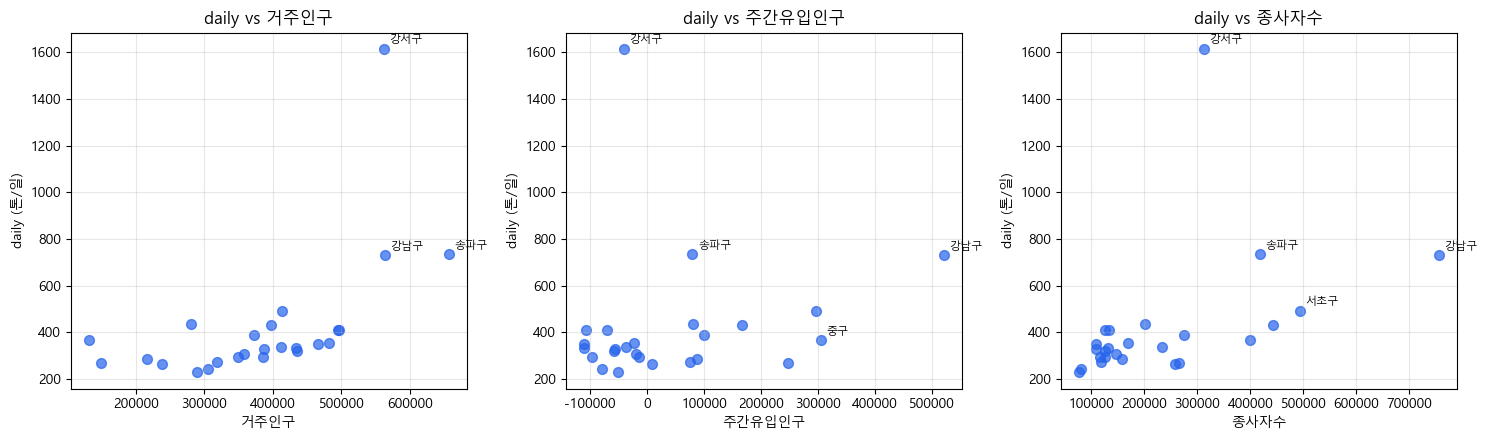

In [10]:
# 2-2. 독립변수 vs daily 산점도
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, xcol in zip(axes, ["거주인구", "주간유입인구", "종사자수"]):
    ax.scatter(df[xcol], df["daily"], s=50, alpha=0.7, color="#2563eb")
    ax.set_xlabel(xcol)
    ax.set_ylabel("daily (톤/일)")
    ax.set_title(f"daily vs {xcol}")
    ax.grid(alpha=0.3)
    # 극단값 라벨 (daily 상위 3개 + 해당 x 극단)
    extreme_idx = set(df.nlargest(3, "daily").index) | set(df.nlargest(2, xcol).index)
    for i in extreme_idx:
        ax.annotate(df.loc[i, "자치구"],
                    (df.loc[i, xcol], df.loc[i, "daily"]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")
plt.tight_layout()
plt.show()

=== 상관계수 ===
              daily  거주인구  주간유입인구  종사자수
daily         1.000     0.555         0.149     0.445
거주인구      0.555     1.000        -0.157     0.242
주간유입인구  0.149    -0.157         1.000     0.869
종사자수      0.445     0.242         0.869     1.000



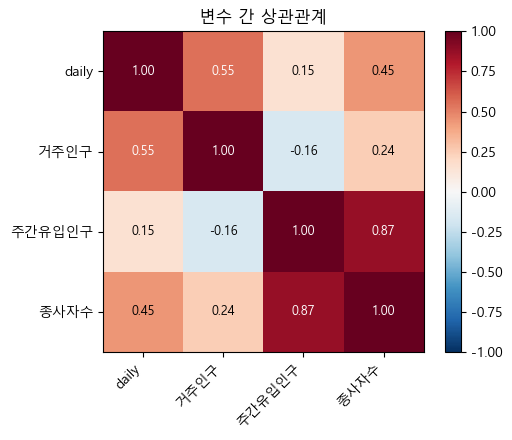

In [11]:
# 2-3. 상관관계 매트릭스
corr = df[["daily", "거주인구", "주간유입인구", "종사자수"]].corr()
print("=== 상관계수 ===")
print(corr.round(3))
print()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}",
                ha="center", va="center",
                color="white" if abs(corr.values[i,j]) > 0.5 else "black",
                fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("변수 간 상관관계")
plt.tight_layout()
plt.show()

**검증 — Step 2**: 극단값 확인 + 다중공선성 사전 경고.

In [12]:
print("=== daily TOP 3 (강남·서초·송파·강서 기대) ===")
print(df.nlargest(3, "daily")[["자치구", "daily"]].to_string(index=False))
print()
print("=== daily BOTTOM 3 (종로·중구·금천 기대) ===")
print(df.nsmallest(3, "daily")[["자치구", "daily"]].to_string(index=False))
print()

# 거주인구 ↔ 종사자수 상관 체크
r_pop_emp = corr.loc["거주인구", "종사자수"]
print(f"거주인구 ↔ 종사자수 상관: {r_pop_emp:.3f}")
if abs(r_pop_emp) >= 0.7:
    print("⚠️  상관 ≥ 0.7 — Step 5에서 VIF로 다중공선성 체크 필요")
else:
    print("✅ 상관 < 0.7 — 다중공선성 우려 낮음")

=== daily TOP 3 (강남·서초·송파·강서 기대) ===
자치구  daily
강서구 1614.5
송파구  734.7
강남구  729.0

=== daily BOTTOM 3 (종로·중구·금천 기대) ===
자치구  daily
강북구  228.4
도봉구  240.7
금천구  264.2

거주인구 ↔ 종사자수 상관: 0.242
✅ 상관 < 0.7 — 다중공선성 우려 낮음


## Step 3. 모형 1 — 베이스라인 (거주인구만)

$$\text{daily} = \beta_0 + \beta_1 \cdot \text{거주인구} + \varepsilon$$

논문(이사라 외, 2008) 방식 재현. 인구 1축만으로 R² 어디까지 가는지 확인.

In [13]:
m1 = smf.ols("daily ~ 거주인구", data=df).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                  daily   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     10.21
Date:                Sat, 02 May 2026   Prob (F-statistic):            0.00402
Time:                        06:48:06   Log-Likelihood:                -171.19
No. Observations:                  25   AIC:                             346.4
Df Residuals:                      23   BIC:                             348.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -49.8954    154.338     -0.323      0.7

**검증 — 모형 1**: 계수 부호·유의성·잔차 진단.

R²       : 0.3075
R²_adj   : 0.2774
AIC      : 346.39
계수     : {'Intercept': -49.8954, '거주인구': 0.0012}
p값      : {'Intercept': 0.7494, '거주인구': 0.004}
✅ 거주인구 계수 양수 & p<0.05


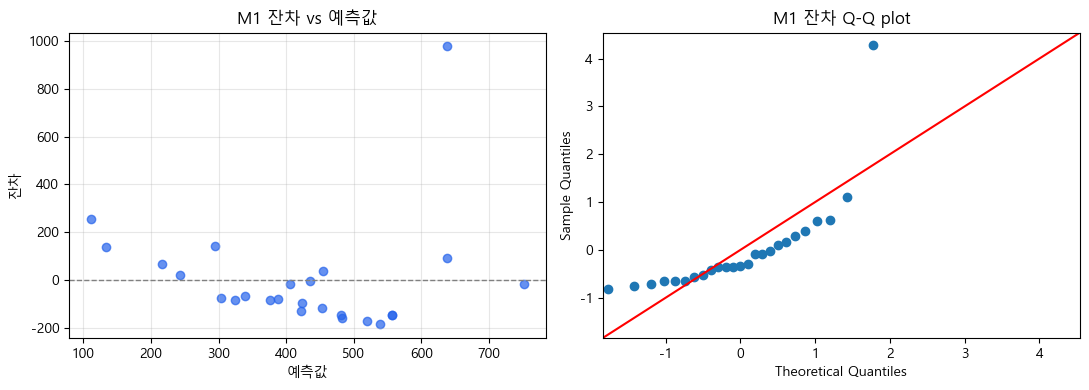

In [14]:
print(f"R²       : {m1.rsquared:.4f}")
print(f"R²_adj   : {m1.rsquared_adj:.4f}")
print(f"AIC      : {m1.aic:.2f}")
print(f"계수     : {dict(m1.params.round(4))}")
print(f"p값      : {dict(m1.pvalues.round(4))}")

assert m1.params["거주인구"] > 0, "거주인구 계수 부호 음수 (이상)"
assert m1.pvalues["거주인구"] < 0.05, "거주인구 유의하지 않음"
print("✅ 거주인구 계수 양수 & p<0.05")

# 잔차 진단 (잔차 vs 예측값, Q-Q plot)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(m1.fittedvalues, m1.resid, color="#2563eb", alpha=0.7)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_xlabel("예측값")
axes[0].set_ylabel("잔차")
axes[0].set_title("M1 잔차 vs 예측값")
axes[0].grid(alpha=0.3)
sm.qqplot(m1.resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("M1 잔차 Q-Q plot")
plt.tight_layout()
plt.show()

## Step 4. 모형 2 — 거주인구 + 주간유입인구

외부에서 들어오는 사람의 폐기물 기여 검증.

In [15]:
m2 = smf.ols("daily ~ 거주인구 + 주간유입인구", data=df).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                  daily   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     6.305
Date:                Sat, 02 May 2026   Prob (F-statistic):            0.00684
Time:                        06:48:06   Log-Likelihood:                -170.12
No. Observations:                  25   AIC:                             346.2
Df Residuals:                      22   BIC:                             349.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -100.6439    155.453     -0.647      0.5

In [16]:
print(f"M2 R²    : {m2.rsquared:.4f}  (M1: {m1.rsquared:.4f}, ΔR² = {m2.rsquared - m1.rsquared:+.4f})")
print(f"M2 AIC   : {m2.aic:.2f}     (M1: {m1.aic:.2f}, ΔAIC = {m2.aic - m1.aic:+.2f})")
print(f"M2 계수  : {dict(m2.params.round(4))}")
print(f"M2 p값   : {dict(m2.pvalues.round(4))}")
print()

for v in ["거주인구", "주간유입인구"]:
    sig = "✓" if m2.pvalues[v] < 0.05 else "✗"
    sign = "양수" if m2.params[v] > 0 else "음수"
    print(f"  {v:12s}: 계수 {sign}, p={m2.pvalues[v]:.4f} {sig}")

# 모형 비교 표 (누적)
compare = pd.DataFrame({
    "모형":      ["M1", "M2"],
    "식":        ["daily ~ 거주인구", "daily ~ 거주인구 + 주간유입인구"],
    "R²":        [m1.rsquared, m2.rsquared],
    "R²_adj":    [m1.rsquared_adj, m2.rsquared_adj],
    "AIC":       [m1.aic, m2.aic],
})
print("\n=== 모형 비교 ===")
print(compare.round(3).to_string(index=False))

M2 R²    : 0.3644  (M1: 0.3075, ΔR² = +0.0569)
M2 AIC   : 346.24     (M1: 346.39, ΔAIC = -0.14)
M2 계수  : {'Intercept': -100.6439, '거주인구': 0.0013, '주간유입인구': 0.0004}
M2 p값   : {'Intercept': 0.5241, '거주인구': 0.0023, '주간유입인구': 0.1745}

  거주인구        : 계수 양수, p=0.0023 ✓
  주간유입인구      : 계수 양수, p=0.1745 ✗

=== 모형 비교 ===
모형                              식    R²  R²_adj     AIC
  M1                daily ~ 거주인구 0.307   0.277 346.386
  M2 daily ~ 거주인구 + 주간유입인구 0.364   0.307 346.244


## Step 5. 모형 3 — 풀 모형 (+ 종사자수)

사업장 활동 추가. **VIF로 다중공선성 진단** (>5 이면 경고, >10 이면 심각).

In [17]:
m3 = smf.ols("daily ~ 거주인구 + 주간유입인구 + 종사자수", data=df).fit()
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                  daily   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     5.745
Date:                Sat, 02 May 2026   Prob (F-statistic):            0.00494
Time:                        06:48:06   Log-Likelihood:                -168.30
No. Observations:                  25   AIC:                             344.6
Df Residuals:                      21   BIC:                             349.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -96.5721    147.920     -0.653      0.5

In [18]:
# VIF 계산
X = df[["거주인구", "주간유입인구", "종사자수"]].copy()
X_with_const = sm.add_constant(X)
vif_rows = []
for i, col in enumerate(X_with_const.columns):
    if col == "const":
        continue
    vif_val = variance_inflation_factor(X_with_const.values,
                                         X_with_const.columns.get_loc(col))
    vif_rows.append({"변수": col, "VIF": vif_val})
vif = pd.DataFrame(vif_rows)
print("=== VIF (Variance Inflation Factor) ===")
print(vif.round(3).to_string(index=False))
print()

high_vif = vif[vif["VIF"] > 5]["변수"].tolist()
if high_vif:
    print(f"⚠️  VIF > 5: {high_vif}")
else:
    print("✅ 모든 변수 VIF ≤ 5")
print()

# 모형 비교 갱신
compare = pd.DataFrame({
    "모형":   ["M1", "M2", "M3"],
    "R²":     [m1.rsquared, m2.rsquared, m3.rsquared],
    "R²_adj": [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
    "AIC":    [m1.aic, m2.aic, m3.aic],
    "k(변수)":[1, 2, 3],
})
print("=== 모형 비교 (M1 → M3) ===")
print(compare.round(3).to_string(index=False))
print()

for v in ["거주인구", "주간유입인구", "종사자수"]:
    sig = "✓" if m3.pvalues[v] < 0.05 else "✗"
    print(f"  {v:12s}: 계수={m3.params[v]:.5f}, p={m3.pvalues[v]:.4f} {sig}")

=== VIF (Variance Inflation Factor) ===
        변수    VIF
    거주인구  2.572
주간유입인구  9.916
    종사자수 10.276

⚠️  VIF > 5: ['주간유입인구', '종사자수']

=== 모형 비교 (M1 → M3) ===
모형    R²  R²_adj     AIC  k(변수)
  M1 0.307   0.277 346.386        1
  M2 0.364   0.307 346.244        2
  M3 0.451   0.372 344.592        3

  거주인구        : 계수=0.00050, p=0.3918 ✗
  주간유입인구      : 계수=-0.00112, p=0.2262 ✗
  종사자수        : 계수=0.00162, p=0.0834 ✗


## Step 6. 모형 4 (선택) — 4유형 더미

같은 인구·종사자에서도 유형별 baseline 차이가 있는지. 혼합형을 reference로 두고 더미 추가.

**채택 규칙**: M4 vs M3 AIC 비교 + 유형 더미가 하나라도 유의(p<0.05)하면 M4, 아니면 M3.

In [19]:
m4 = smf.ols(
    "daily ~ 거주인구 + 주간유입인구 + 종사자수 + C(유형, Treatment(reference='혼합형'))",
    data=df
).fit()
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:                  daily   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     3.214
Date:                Sat, 02 May 2026   Prob (F-statistic):             0.0252
Time:                        06:48:06   Log-Likelihood:                -166.68
No. Observations:                  25   AIC:                             347.4
Df Residuals:                      18   BIC:                             355.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [20]:
# 유형 더미 계수만 골라내기
type_dummy_pvals = {k: v for k, v in m4.pvalues.items() if k.startswith("C(유형")}
print("=== 유형 더미 p값 ===")
for k, v in type_dummy_pvals.items():
    sig = "✓" if v < 0.05 else "✗"
    short = k.replace("C(유형, Treatment(reference='혼합형'))", "유형")
    print(f"  {short:30s} p={v:.4f} {sig}")
print()

any_dummy_sig = any(p < 0.05 for p in type_dummy_pvals.values())
delta_aic = m4.aic - m3.aic

print(f"M3 AIC: {m3.aic:.2f}")
print(f"M4 AIC: {m4.aic:.2f}  (ΔAIC = {delta_aic:+.2f})")
print(f"M3 R²: {m3.rsquared:.4f}, M4 R²: {m4.rsquared:.4f}")
print()

# 채택 결정
if any_dummy_sig and delta_aic < 0:
    final_model = m4
    final_label = "M4 (4유형 더미 포함)"
    print(f"➡️  최종 모형: {final_label}")
    print("   이유: 유형 더미 중 하나 이상 유의 + AIC 감소")
else:
    final_model = m3
    final_label = "M3 (인구·유입·종사자수)"
    print(f"➡️  최종 모형: {final_label}")
    if not any_dummy_sig:
        print("   이유: 유형 더미가 모두 p≥0.05 (의미 있는 그룹 차이 없음)")
    else:
        print("   이유: AIC가 더 큼 (모형 복잡도 대비 이득 없음)")

# 비교 표 최종
compare = pd.DataFrame({
    "모형":   ["M1", "M2", "M3", "M4"],
    "R²":     [m1.rsquared, m2.rsquared, m3.rsquared, m4.rsquared],
    "R²_adj": [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj, m4.rsquared_adj],
    "AIC":    [m1.aic, m2.aic, m3.aic, m4.aic],
})
print("\n=== 최종 모형 비교 ===")
print(compare.round(3).to_string(index=False))

=== 유형 더미 p값 ===
  유형[T.상업형]                      p=0.2219 ✗
  유형[T.유동집중형]                    p=0.5255 ✗
  유형[T.주거형]                      p=0.5422 ✗

M3 AIC: 344.59
M4 AIC: 347.36  (ΔAIC = +2.77)
M3 R²: 0.4507, M4 R²: 0.5173

➡️  최종 모형: M3 (인구·유입·종사자수)
   이유: 유형 더미가 모두 p≥0.05 (의미 있는 그룹 차이 없음)

=== 최종 모형 비교 ===
모형    R²  R²_adj     AIC
  M1 0.307   0.277 346.386
  M2 0.364   0.307 346.244
  M3 0.451   0.372 344.592
  M4 0.517   0.356 347.365


## Step 7. 모델 진단 (잔차 분석)

조정지표는 잔차의 의미가 핵심. 잔차의 분포·이상치·영향력을 점검.

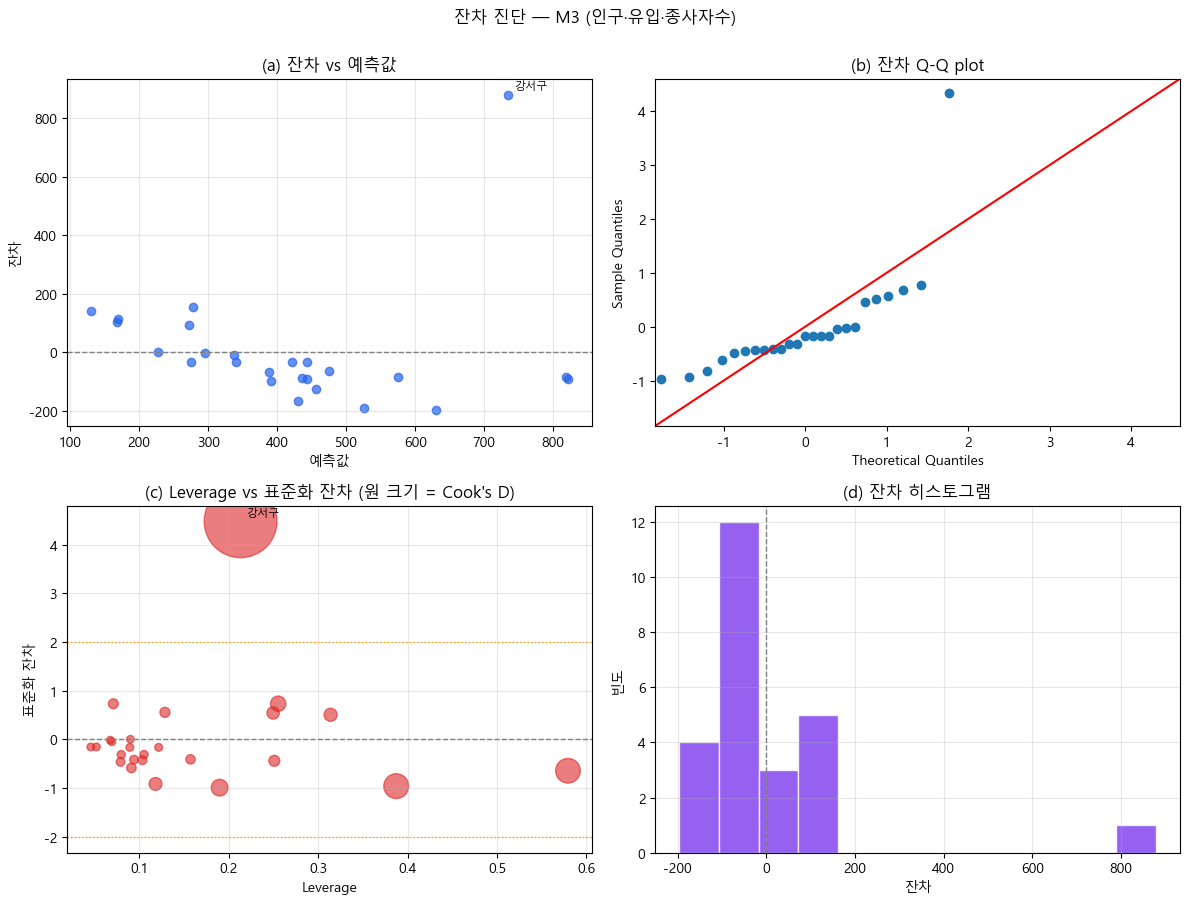

In [21]:
influence = final_model.get_influence()
std_resid = influence.resid_studentized_internal
leverage  = influence.hat_matrix_diag
cooks     = influence.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) 잔차 vs 예측값
axes[0, 0].scatter(final_model.fittedvalues, final_model.resid,
                   color="#2563eb", alpha=0.7)
axes[0, 0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0, 0].set_xlabel("예측값")
axes[0, 0].set_ylabel("잔차")
axes[0, 0].set_title("(a) 잔차 vs 예측값")
axes[0, 0].grid(alpha=0.3)
for i, gu in enumerate(df["자치구"]):
    if abs(std_resid[i]) > 2:
        axes[0, 0].annotate(gu, (final_model.fittedvalues.iloc[i], final_model.resid.iloc[i]),
                            fontsize=8, xytext=(4, 4), textcoords="offset points")

# (b) Q-Q plot
sm.qqplot(final_model.resid, line="45", fit=True, ax=axes[0, 1])
axes[0, 1].set_title("(b) 잔차 Q-Q plot")

# (c) 표준화 잔차 vs leverage + Cook's distance
axes[1, 0].scatter(leverage, std_resid, s=cooks*2000+30,
                   alpha=0.6, color="#dc2626")
axes[1, 0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1, 0].axhline(2, color="orange", linestyle=":", linewidth=1)
axes[1, 0].axhline(-2, color="orange", linestyle=":", linewidth=1)
axes[1, 0].set_xlabel("Leverage")
axes[1, 0].set_ylabel("표준화 잔차")
axes[1, 0].set_title("(c) Leverage vs 표준화 잔차 (원 크기 = Cook's D)")
axes[1, 0].grid(alpha=0.3)
for i, gu in enumerate(df["자치구"]):
    if cooks[i] > 4/len(df) or abs(std_resid[i]) > 2:
        axes[1, 0].annotate(gu, (leverage[i], std_resid[i]),
                            fontsize=8, xytext=(4, 4), textcoords="offset points")

# (d) 잔차 히스토그램
axes[1, 1].hist(final_model.resid, bins=12, color="#7c3aed",
                edgecolor="white", alpha=0.8)
axes[1, 1].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[1, 1].set_xlabel("잔차")
axes[1, 1].set_ylabel("빈도")
axes[1, 1].set_title("(d) 잔차 히스토그램")
axes[1, 1].grid(alpha=0.3)

plt.suptitle(f"잔차 진단 — {final_label}", y=1.00, fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# Shapiro-Wilk 정규성 검정
sw_stat, sw_p = scistats.shapiro(final_model.resid)
print(f"Shapiro-Wilk 정규성: stat={sw_stat:.4f}, p={sw_p:.4f}")
if sw_p > 0.05:
    print("  ✅ 잔차 정규성 가정 충족 (p > 0.05)")
else:
    print("  ⚠️  정규성 미충족 (n=25 소표본에서는 흔함; 잔차 해석은 가능)")
print()

# 표준화 잔차 |z| > 2
outlier_mask = np.abs(std_resid) > 2
outliers = df.loc[outlier_mask, ["자치구", "daily"]].copy()
outliers["표준화_잔차"] = std_resid[outlier_mask]
print(f"=== 표준화 잔차 |z|>2 자치구 ({outlier_mask.sum()}개) ===")
if len(outliers) > 0:
    print(outliers.round(3).to_string(index=False))
else:
    print("  (없음)")
print()

# Cook's distance > 4/n
cd_threshold = 4 / len(df)
high_cd_mask = cooks > cd_threshold
high_cd = df.loc[high_cd_mask, ["자치구", "daily"]].copy()
high_cd["Cooks_D"] = cooks[high_cd_mask]
print(f"=== Cook's D > {cd_threshold:.3f} 영향력 큰 자치구 ({high_cd_mask.sum()}개) ===")
if len(high_cd) > 0:
    print(high_cd.round(4).to_string(index=False))
else:
    print("  (없음)")
print()

if high_cd_mask.sum() > 5:
    print("⚠️  영향력 큰 자치구 5개 초과 — 모형 불안정 가능")
else:
    print("✅ 영향력 큰 자치구 5개 이하 — 모형 안정")

Shapiro-Wilk 정규성: stat=0.6368, p=0.0000
  ⚠️  정규성 미충족 (n=25 소표본에서는 흔함; 잔차 해석은 가능)

=== 표준화 잔차 |z|>2 자치구 (1개) ===
자치구  daily  표준화_잔차
강서구 1614.5        4.479

=== Cook's D > 0.160 영향력 큰 자치구 (1개) ===
자치구  daily  Cooks_D
강서구 1614.5   1.3588

✅ 영향력 큰 자치구 5개 이하 — 모형 안정


## Step 8. 조정지표 산출 + 5분류

$$\text{조정지표} = \frac{\text{daily}}{\text{예측값}}$$

예측값 대비 실제 발생량 비율로 5분류 (우수·양호·적정·주의·과다).

In [23]:
df = df.copy()
df["예측값"] = final_model.fittedvalues.values
df["잔차"]  = df["daily"] - df["예측값"]
df["조정지표"] = df["daily"] / df["예측값"]

def classify_index(idx):
    if idx >= 1.2:   return "과다"
    elif idx >= 1.1: return "주의"
    elif idx >= 0.9: return "적정"
    elif idx >= 0.8: return "양호"
    else:            return "우수"

df["배출분류"] = df["조정지표"].apply(classify_index)

print("=== 조정지표 describe ===")
print(df["조정지표"].describe().round(3))
print()
print("=== 배출분류 분포 ===")
order = ["과다", "주의", "적정", "양호", "우수"]
print(df["배출분류"].value_counts().reindex(order, fill_value=0).to_string())

=== 조정지표 describe ===
count    25.000
mean      1.057
std       0.434
min       0.614
25%       0.800
50%       0.897
75%       1.004
max       2.197
Name: 조정지표, dtype: float64

=== 배출분류 분포 ===
배출분류
과다    6
주의    0
적정    6
양호    6
우수    7


In [24]:
print("=== 분류별 자치구 명단 ===")
for cls in ["과다", "주의", "적정", "양호", "우수"]:
    members = df[df["배출분류"] == cls].sort_values("조정지표", ascending=False)
    if len(members) == 0:
        print(f"  [{cls}]  (없음)")
        continue
    parts = [f"{r['자치구']}({r['조정지표']:.2f})" for _, r in members.iterrows()]
    print(f"  [{cls}] {len(members)}개 — " + " · ".join(parts))
print()

# 직관 검증
print("=== 직관 검증 ===")
checkpoints = {
    "종로구": "적정 근처 기대 (1인당은 높지만 유동인구 통제 후)",
    "중구":   "적정 근처 기대 (오피스 통제 후)",
    "강서구": "사업장 비중 높음 — 통제 후 분류 변화 관찰",
    "노원구": "적정 근처 기대 (주거형)",
    "도봉구": "적정 근처 기대 (주거형)",
}
for gu, expect in checkpoints.items():
    if gu in df["자치구"].values:
        row = df[df["자치구"] == gu].iloc[0]
        print(f"  {gu:6s} 조정지표={row['조정지표']:.3f} → {row['배출분류']:4s} | {expect}")
print()

# 분류별 평균 조정지표
print("=== 분류별 평균 조정지표 (각 분류 정의대로 떨어지는지) ===")
print(df.groupby("배출분류")["조정지표"].agg(["mean", "min", "max", "count"])
        .round(3).reindex(order).dropna().to_string())

=== 분류별 자치구 명단 ===
  [과다] 6개 — 강서구(2.20) · 종로구(2.08) · 용산구(1.68) · 서대문구(1.62) · 성동구(1.56) · 중구(1.34)
  [주의]  (없음)
  [적정] 6개 — 강북구(1.00) · 광진구(0.99) · 동작구(0.97) · 노원구(0.92) · 마포구(0.92) · 동대문구(0.90)
  [양호] 6개 — 송파구(0.90) · 강남구(0.89) · 도봉구(0.87) · 관악구(0.86) · 서초구(0.86) · 성북구(0.83)
  [우수] 7개 — 은평구(0.80) · 강동구(0.80) · 중랑구(0.75) · 양천구(0.73) · 영등포구(0.69) · 구로구(0.64) · 금천구(0.61)

=== 직관 검증 ===
  종로구    조정지표=2.077 → 과다   | 적정 근처 기대 (1인당은 높지만 유동인구 통제 후)
  중구     조정지표=1.342 → 과다   | 적정 근처 기대 (오피스 통제 후)
  강서구    조정지표=2.197 → 과다   | 사업장 비중 높음 — 통제 후 분류 변화 관찰
  노원구    조정지표=0.924 → 적정   | 적정 근처 기대 (주거형)
  도봉구    조정지표=0.874 → 양호   | 적정 근처 기대 (주거형)

=== 분류별 평균 조정지표 (각 분류 정의대로 떨어지는지) ===
           mean    min    max  count
배출분류                            
과다      1.747  1.342  2.197    6.0
적정      0.952  0.903  1.004    6.0
양호      0.868  0.829  0.897    6.0
우수      0.717  0.614  0.800    7.0


## Step 9. 결과 시각화 + CSV 저장

- 9-1. 실제 vs 예측 산점도 (45도 점선)
- 9-2. 자치구별 조정지표 막대 그래프 (1.0 기준선)
- 9-3. CSV 저장

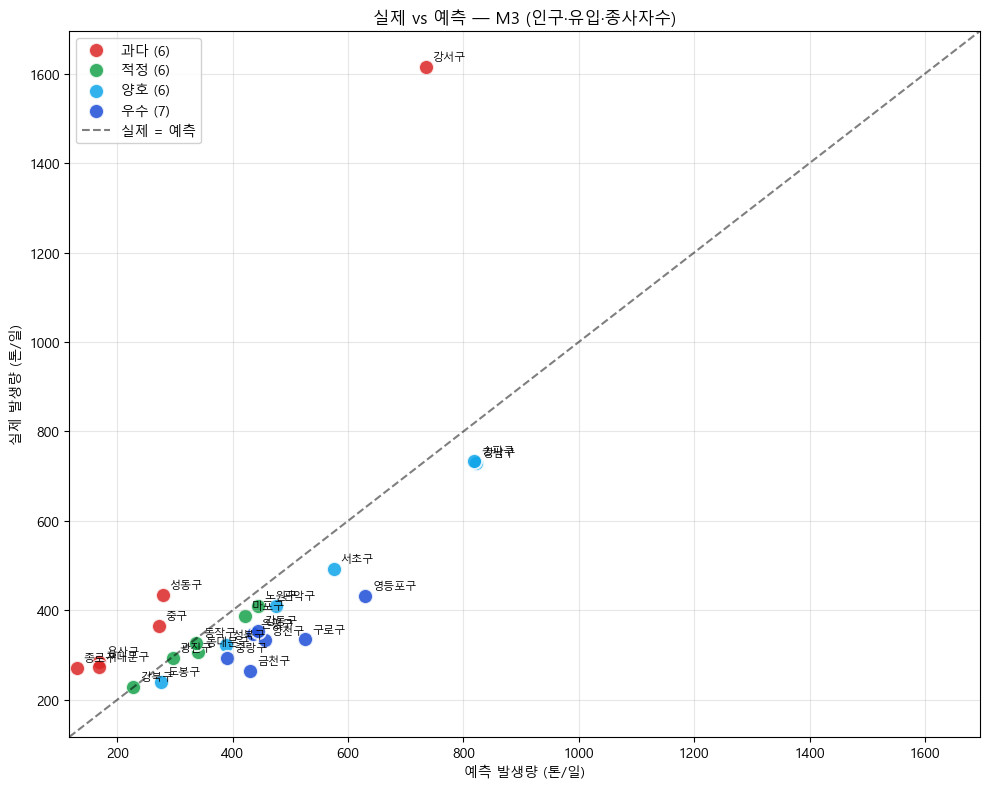

In [25]:
# 9-1. 실제 vs 예측 산점도
CLS_COLOR = {
    "과다": "#dc2626",  # 빨강
    "주의": "#f59e0b",  # 주황
    "적정": "#16a34a",  # 초록
    "양호": "#0ea5e9",  # 하늘
    "우수": "#1d4ed8",  # 파랑
}

fig, ax = plt.subplots(figsize=(10, 8))
for cls, color in CLS_COLOR.items():
    sub = df[df["배출분류"] == cls]
    if len(sub) == 0:
        continue
    ax.scatter(sub["예측값"], sub["daily"], s=120, c=color,
               label=f"{cls} ({len(sub)})", alpha=0.85,
               edgecolor="white", linewidth=1.5)

for _, r in df.iterrows():
    ax.annotate(r["자치구"], (r["예측값"], r["daily"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

lim = [min(df["예측값"].min(), df["daily"].min()) * 0.9,
       max(df["예측값"].max(), df["daily"].max()) * 1.05]
ax.plot(lim, lim, "k--", alpha=0.5, label="실제 = 예측")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("예측 발생량 (톤/일)")
ax.set_ylabel("실제 발생량 (톤/일)")
ax.set_title(f"실제 vs 예측 — {final_label}")
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

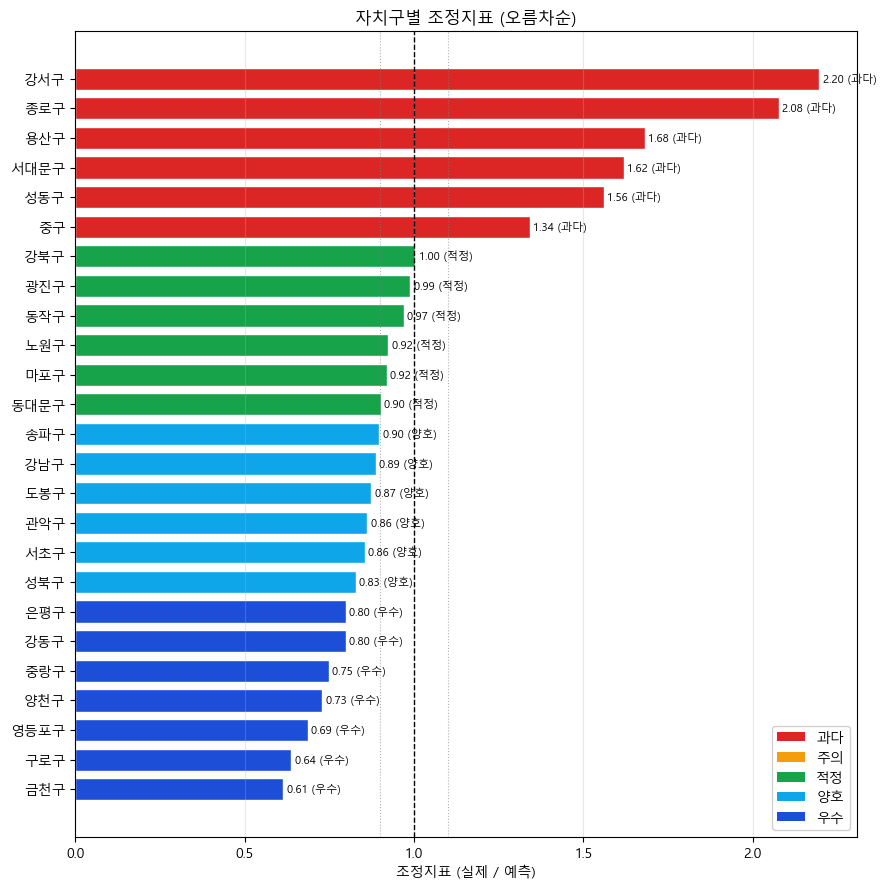

In [26]:
# 9-2. 자치구별 조정지표 막대 그래프
df_sorted = df.sort_values("조정지표", ascending=True)
colors = [CLS_COLOR[c] for c in df_sorted["배출분류"]]

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(df_sorted["자치구"], df_sorted["조정지표"], color=colors,
        edgecolor="white", height=0.75)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="기준선 (1.0)")
ax.axvline(0.9, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.axvline(1.1, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.set_xlabel("조정지표 (실제 / 예측)")
ax.set_title("자치구별 조정지표 (오름차순)")
for i, (idx_val, cls) in enumerate(zip(df_sorted["조정지표"], df_sorted["배출분류"])):
    ax.text(idx_val + 0.01, i, f"{idx_val:.2f} ({cls})",
            va="center", fontsize=8)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=k) for k, c in CLS_COLOR.items()]
ax.legend(handles=legend_handles, loc="lower right", framealpha=0.9)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

In [27]:
# 9-3. CSV 저장
out_cols = ["자치구", "거주인구", "주간유입인구", "종사자수", "유형",
            "daily", "예측값", "잔차", "조정지표", "배출분류"]
out_path = os.path.join(PREPROC_DIR, "gu_waste_adjusted.csv")
df[out_cols].to_csv(out_path, encoding="utf-8-sig", index=False)

print(f"✅ 저장 완료: {out_path}")
print(f"   ({os.path.getsize(out_path):,} bytes)")

✅ 저장 완료: d:\바탕화면\BAF\환경_대시보드\seoul-bigdata\data\preprocess\gu_waste_adjusted.csv
   (3,039 bytes)


In [28]:
# 저장된 CSV 다시 읽어 검증
saved = pd.read_csv(out_path, encoding="utf-8-sig")
print("저장된 shape:", saved.shape)
print("컬럼:", saved.columns.tolist())
print()
print(saved.head().to_string(index=False))
print()

# 합계 검증
assert len(saved) == 25
assert saved["배출분류"].value_counts().sum() == 25
assert saved.isna().sum().sum() == 0

print("=== 분류별 평균 조정지표 ===")
print(saved.groupby("배출분류")["조정지표"]
        .agg(["count", "mean", "min", "max"]).round(3)
        .reindex(["과다", "주의", "적정", "양호", "우수"]).dropna().to_string())
print()

print(f"최종 모형 R²    : {final_model.rsquared:.4f}")
print(f"최종 모형 R²_adj: {final_model.rsquared_adj:.4f}")
if final_model.rsquared > 0.7:
    print("✅ R² > 0.7 (목표 달성)")
else:
    print("⚠️  R² ≤ 0.7 (소표본 회귀 한계 — 잔차 해석 위주로 활용)")

print("\n🎉 모든 Step 완료 — gu_waste_adjusted.csv 생성됨")

저장된 shape: (25, 10)
컬럼: ['자치구', '거주인구', '주간유입인구', '종사자수', '유형', 'daily', '예측값', '잔차', '조정지표', '배출분류']

자치구  거주인구  주간유입인구  종사자수       유형  daily     예측값       잔차  조정지표 배출분류
종로구    149608  246821.18750    265635     상업형  270.2 130.078162 140.121838  2.077213     과다
  중구    131214  305489.46875    399960     상업형  365.0 272.076859  92.923141  1.341533     과다
용산구    217194   87074.25000    157564 유동집중형  283.9 168.820303 115.079697  1.681670     과다
성동구    281289   80325.31250    201023     혼합형  435.1 278.721552 156.378448  1.561056     과다
광진구    348652  -13851.90625    125475 유동집중형  293.0 296.181050  -3.181050  0.989260     적정

=== 분류별 평균 조정지표 ===
          count   mean    min    max
배출분류                            
과다        6.0  1.747  1.342  2.197
적정        6.0  0.952  0.903  1.004
양호        6.0  0.868  0.829  0.897
우수        7.0  0.717  0.614  0.800

최종 모형 R²    : 0.4507
최종 모형 R²_adj: 0.3723
⚠️  R² ≤ 0.7 (소표본 회귀 한계 — 잔차 해석 위주로 활용)

🎉 모든 Step 완료 — gu_waste_adjusted.csv 생성됨
